# Stroke Prediction: Explainable AI

This notebook applies three interpretable machine learning models to the [Healthcare Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) (fedesoriano, Kaggle).

Each model produces both **global** explanations (population-level feature behaviour) and **local** explanations (individual patient-level reasoning).

| Model | Global XAI | Local XAI |
|---|---|---|
| Explainable Boosting Machine (EBM) | Feature importances, shape functions | Per-patient contribution bars |
| Classification Tree | Tree plot, feature importances | Decision path contributions |
| Logistic Regression | Odds-ratio plot | SHAP waterfall |

**Primary metric:** PR-AUC (preferred over ROC-AUC for imbalanced datasets).
**Class imbalance handling:** `class_weight='balanced'` on all three models. The dataset is ~95% no-stroke / 5% stroke, so the balanced weight penalises stroke misclassifications ~19x more heavily than no-stroke misclassifications during training.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

from interpret.glassbox import ExplainableBoostingClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = "healthcare-dataset-stroke-data.csv"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

## 1. Data Exploration

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Data types:


id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


Missing values:


,missing_count,missing_pct
bmi,201,3.93



Class distribution:


,count,percentage
stroke,,
0,4861,95.13
1,249,4.87


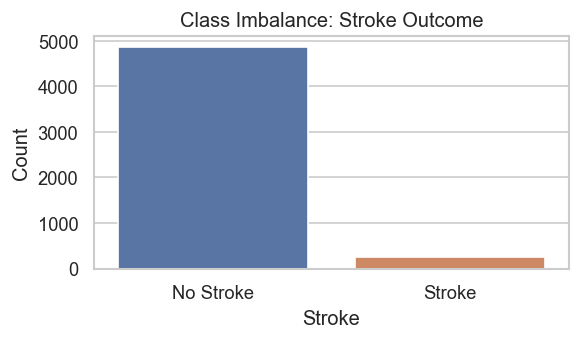

In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head(5))

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
missing_table = df.isnull().sum().to_frame(name="missing_count")
missing_table["missing_pct"] = (missing_table["missing_count"] / len(df) * 100).round(2)
display(missing_table[missing_table["missing_count"] > 0])

print("\nClass distribution:")
class_counts = df["stroke"].value_counts().sort_index()
class_pcts = (df["stroke"].value_counts(normalize=True).sort_index() * 100).round(2)
display(pd.DataFrame({"count": class_counts, "percentage": class_pcts}))

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x="stroke", palette=["#4C72B0", "#DD8452"])
plt.title("Class Imbalance: Stroke Outcome")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.tight_layout()
plt.show()

## 2. Preprocessing

Class imbalance (~95/5) is handled via `class_weight='balanced'` on each model rather than resampling. This instructs the loss function to penalise stroke misclassifications ~19x more than no-stroke misclassifications, preserving the original data distribution while correcting the decision boundary.

In [3]:
df_model = df.copy()

df_model = df_model.dropna(subset=["bmi"]).reset_index(drop=True)

df_model["gender"] = df_model["gender"].map({"Male": 1, "Female": 0, "Other": -1})
df_model["ever_married"] = df_model["ever_married"].map({"Yes": 1, "No": 0})
df_model["Residence_type"] = df_model["Residence_type"].map({"Urban": 1, "Rural": 0})

df_model = pd.get_dummies(
    df_model,
    columns=["work_type", "smoking_status"],
    drop_first=True,
    dtype=int,
)

if "id" in df_model.columns:
    df_model = df_model.drop(columns=["id"])

X = df_model.drop(columns=["stroke"])
y = df_model["stroke"].astype(int)

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape    :", X_test.shape)
print("y_train distribution:", y_train.value_counts().to_dict())
print("y_test  distribution:", y_test.value_counts().to_dict())

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_names)

Training set shape: (3927, 15)
Test set shape    : (982, 15)
y_train distribution: {0: 3760, 1: 167}
y_test  distribution: {0: 940, 1: 42}


## 3. Explainable Boosting Machine (EBM)

EBMs (InterpretML) are a modern GA2M model that learns feature shape functions independently via boosting. They match the accuracy of gradient boosted trees while remaining fully interpretable.

EBM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       940
           1       0.11      0.71      0.19        42

    accuracy                           0.75       982
   macro avg       0.55      0.73      0.52       982
weighted avg       0.95      0.75      0.82       982

ROC-AUC : 0.8101
PR-AUC  : 0.1876


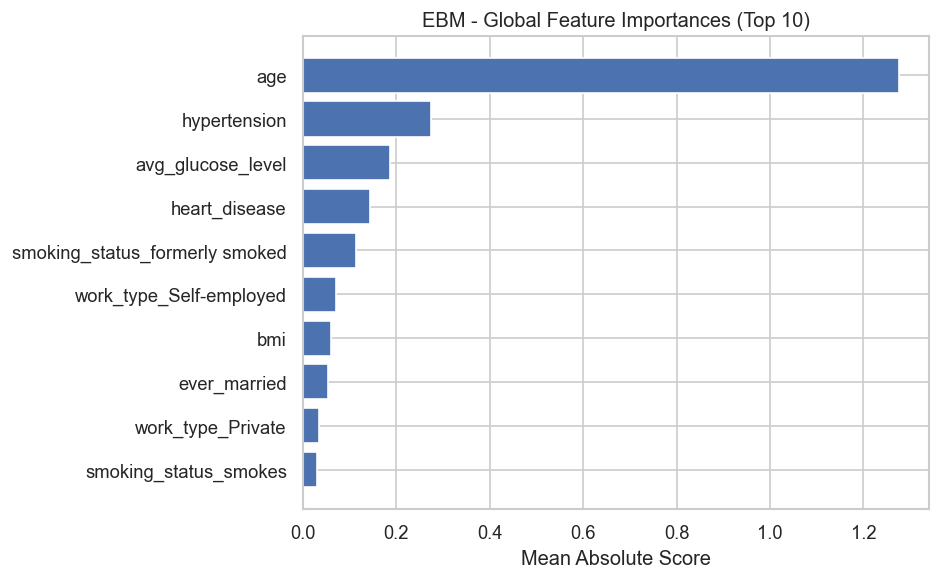

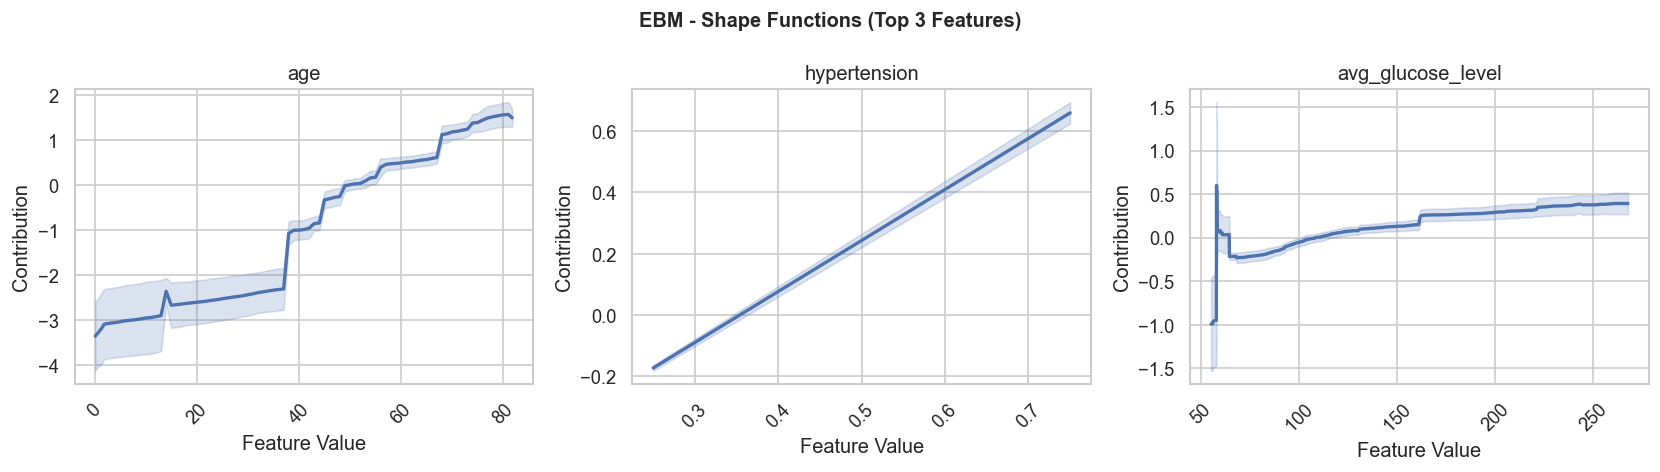

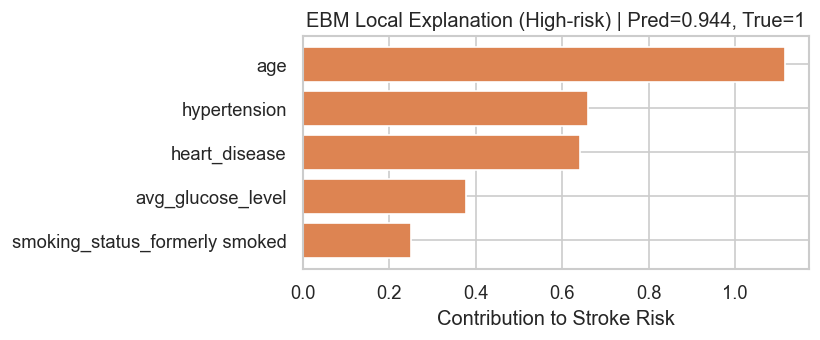

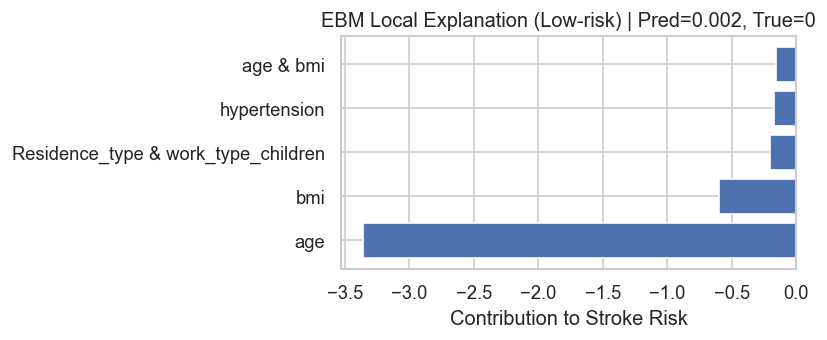

In [4]:
ebm = ExplainableBoostingClassifier(random_state=RANDOM_STATE)
ebm_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
ebm.fit(X_train, y_train, sample_weight=ebm_sample_weights)

ebm_proba = ebm.predict_proba(X_test)[:, 1]
ebm_pred  = ebm.predict(X_test)

print("EBM Classification Report:")
print(classification_report(y_test, ebm_pred, zero_division=0))
print(f"ROC-AUC : {roc_auc_score(y_test, ebm_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, ebm_proba):.4f}")

# -- Global: feature importances --
ebm_global  = ebm.explain_global()
global_data = ebm_global.data()

ebm_importances = (
    pd.DataFrame({"feature": global_data["names"], "importance": global_data["scores"]})
    .sort_values("importance", ascending=False)
)

top10_ebm = ebm_importances.head(10).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(top10_ebm["feature"], top10_ebm["importance"], color="#4C72B0")
plt.title("EBM - Global Feature Importances (Top 10)")
plt.xlabel("Mean Absolute Score")
plt.tight_layout()
plt.show()

# -- Global: shape functions for top 3 features --
# Build a map from feature name to its term index (main effects only)
term_name_to_idx = {}
for i, tf in enumerate(ebm.term_features_):
    if len(tf) == 1:
        name = ebm.feature_names_in_[tf[0]]
        term_name_to_idx[name] = i

# Select top 3 from importances that have main-effect terms
top3_features = [
    f for f in ebm_importances["feature"].tolist()
    if f in term_name_to_idx
][:3]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feature in zip(axes, top3_features):
    term_idx  = term_name_to_idx[feature]
    feat_data = ebm_global.data(term_idx)
    raw_names = feat_data["names"]
    y_vals    = np.asarray(feat_data["scores"])
    # Continuous features return n+1 bin edges and n scores; use midpoints
    if len(raw_names) == len(y_vals) + 1:
        edges  = np.asarray(raw_names, dtype=float)
        x_vals = (edges[:-1] + edges[1:]) / 2
    else:
        x_vals = np.arange(len(y_vals))
    ax.plot(x_vals, y_vals, color="#4C72B0", linewidth=2)
    lower = feat_data.get("lower_bounds")
    upper = feat_data.get("upper_bounds")
    if lower is not None and upper is not None:
        lb = np.asarray(lower)
        ub = np.asarray(upper)
        if len(lb) == len(x_vals) and len(ub) == len(x_vals):
            ax.fill_between(x_vals, lb, ub, color="#4C72B0", alpha=0.2)
    ax.set_title(feature)
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Contribution")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("EBM - Shape Functions (Top 3 Features)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# -- Local: high-risk and low-risk patients --
patient_cases = {
    "High-risk": int(np.argmax(ebm_proba)),
    "Low-risk":  int(np.argmin(ebm_proba)),
}

for case_name, pos in patient_cases.items():
    patient_df   = X_test.iloc[[pos]]
    true_label   = int(y_test.iloc[pos])
    pred_prob    = float(ebm.predict_proba(patient_df)[:, 1][0])
    local_exp    = ebm.explain_local(patient_df)
    local_data   = local_exp.data(0)
    local_scores = (
        pd.DataFrame({"feature": local_data["names"], "contribution": local_data["scores"]})
        .assign(abs_contribution=lambda d: d["contribution"].abs())
        .nlargest(5, "abs_contribution")
        .sort_values("contribution", ascending=True)
        .drop(columns="abs_contribution")
    )
    colors = np.where(local_scores["contribution"] >= 0, "#DD8452", "#4C72B0")
    plt.figure(figsize=(7, 3))
    plt.barh(local_scores["feature"], local_scores["contribution"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(
        f"EBM Local Explanation ({case_name}) | "
        f"Pred={pred_prob:.3f}, True={true_label}"
    )
    plt.xlabel("Contribution to Stroke Risk")
    plt.tight_layout()
    plt.show()

## 4. Classification Tree

A depth-constrained decision tree offers the most directly human-readable model: every prediction can be traced through a sequence of binary splits.

Classification Tree Report:
              precision    recall  f1-score   support

           0       0.98      0.73      0.84       940
           1       0.10      0.69      0.18        42

    accuracy                           0.73       982
   macro avg       0.54      0.71      0.51       982
weighted avg       0.94      0.73      0.81       982

ROC-AUC : 0.7871
PR-AUC  : 0.1268


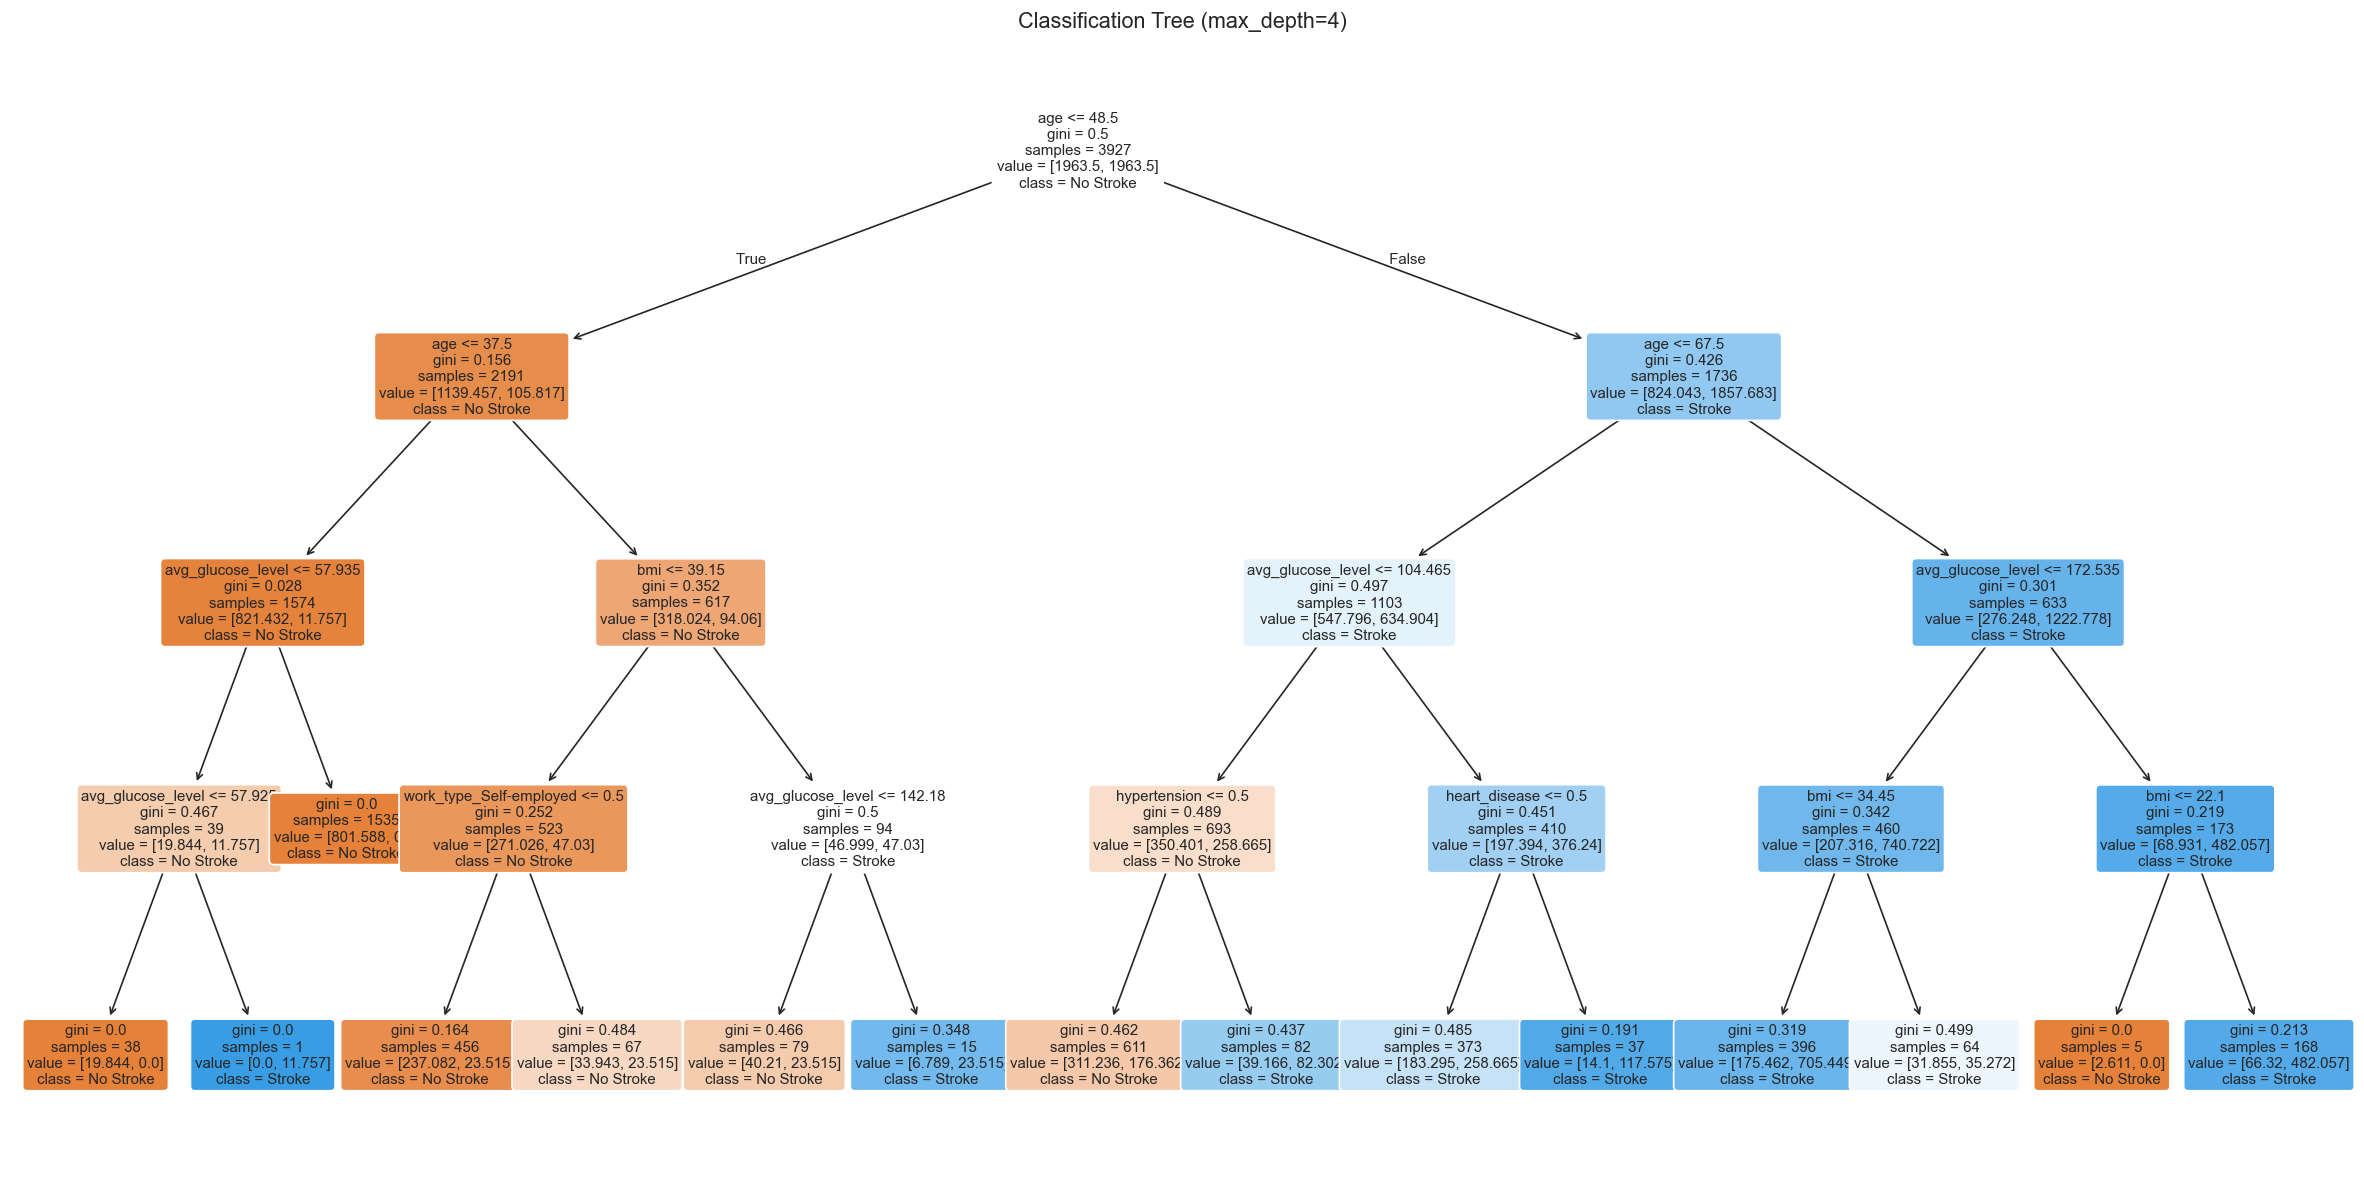

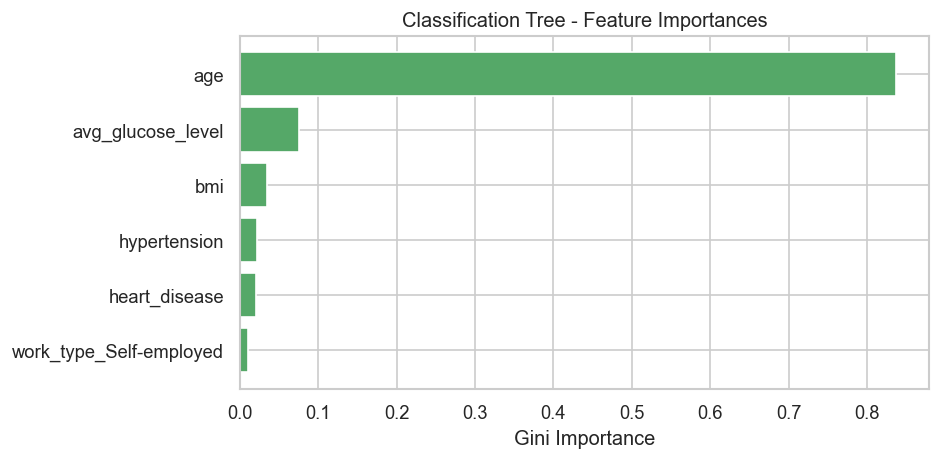


High-risk patient | Pred=0.879, True=1


,node,feature,patient_value,threshold,direction
0,0,age,68.00,48.500,>
1,14,age,68.00,67.500,>
2,22,avg_glucose_level,247.51,172.535,>
3,26,bmi,40.50,22.100,>


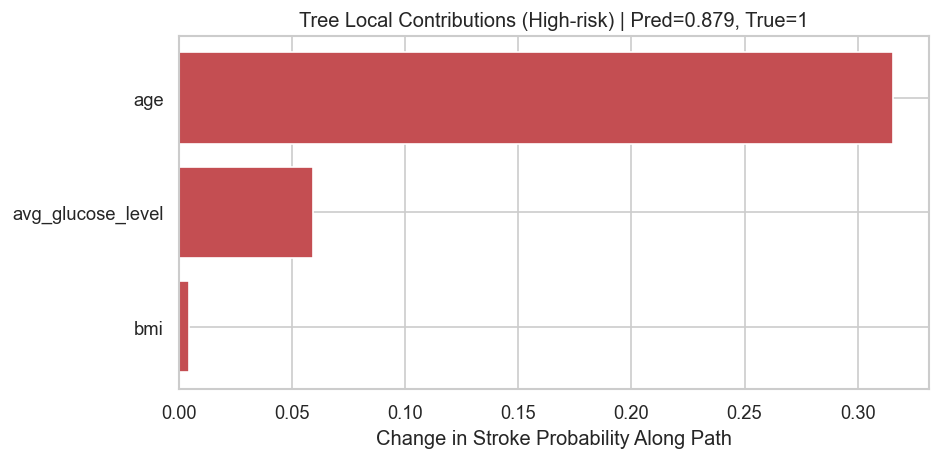


Low-risk patient | Pred=0.000, True=0


,node,feature,patient_value,threshold,direction
0,0,age,0.16,48.500,<=
1,1,age,0.16,37.500,<=
2,2,avg_glucose_level,109.52,57.935,>


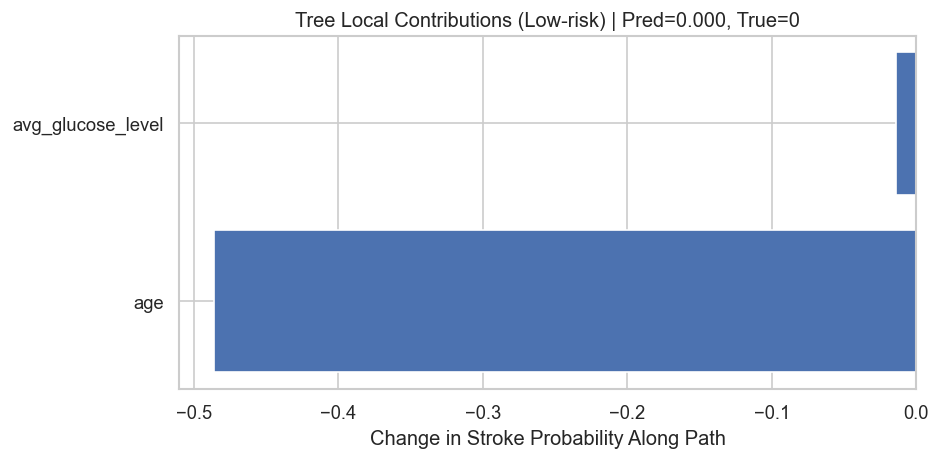

In [5]:
tree_model = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)

tree_proba = tree_model.predict_proba(X_test)[:, 1]
tree_pred  = tree_model.predict(X_test)

print("Classification Tree Report:")
print(classification_report(y_test, tree_pred, zero_division=0))
print(f"ROC-AUC : {roc_auc_score(y_test, tree_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, tree_proba):.4f}")

# -- Global: tree plot --
plt.figure(figsize=(20, 10))
tree.plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["No Stroke", "Stroke"],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Classification Tree (max_depth=4)", fontsize=13)
plt.tight_layout()
plt.show()

# -- Global: feature importances --
tree_importances = (
    pd.DataFrame({"feature": feature_names, "importance": tree_model.feature_importances_})
    .query("importance > 0")
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(8, 4))
plt.barh(tree_importances["feature"], tree_importances["importance"], color="#55A868")
plt.title("Classification Tree - Feature Importances")
plt.xlabel("Gini Importance")
plt.tight_layout()
plt.show()


def _tree_path_table(model, patient_row, features):
    node_indicator = model.decision_path(patient_row)
    leaf_id = model.apply(patient_row)[0]
    nodes = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    rows = []
    for node_id in nodes:
        if node_id == leaf_id:
            continue
        fi        = model.tree_.feature[node_id]
        threshold = model.tree_.threshold[node_id]
        value     = patient_row.iloc[0, fi]
        rows.append({
            "node": node_id,
            "feature": features[fi],
            "patient_value": round(float(value), 4),
            "threshold": round(float(threshold), 4),
            "direction": "<=" if value <= threshold else ">",
        })
    return pd.DataFrame(rows)


def _tree_path_contributions(model, patient_row, features):
    node_indicator = model.decision_path(patient_row)
    nodes    = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    vals     = model.tree_.value
    contribs = []
    for parent, child in zip(nodes[:-1], nodes[1:]):
        fi = model.tree_.feature[parent]
        if fi < 0:
            continue
        p_counts = vals[parent][0]
        c_counts = vals[child][0]
        delta    = c_counts[1] / c_counts.sum() - p_counts[1] / p_counts.sum()
        contribs.append({"feature": features[fi], "contribution": delta})
    if not contribs:
        return pd.DataFrame(columns=["feature", "contribution"])
    return (
        pd.DataFrame(contribs)
        .groupby("feature", as_index=False)["contribution"].sum()
        .sort_values("contribution", ascending=True)
    )


for case_name, pos in patient_cases.items():
    patient_df = X_test.iloc[[pos]]
    true_label = int(y_test.iloc[pos])
    pred_prob  = float(tree_model.predict_proba(patient_df)[:, 1][0])

    print(f"\n{case_name} patient | Pred={pred_prob:.3f}, True={true_label}")
    display(_tree_path_table(tree_model, patient_df, feature_names))

    contrib_df = _tree_path_contributions(tree_model, patient_df, feature_names)
    if contrib_df.empty:
        print("No multi-node path available.")
        continue
    colors = np.where(contrib_df["contribution"] >= 0, "#C44E52", "#4C72B0")
    plt.figure(figsize=(8, 4))
    plt.barh(contrib_df["feature"], contrib_df["contribution"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(
        f"Tree Local Contributions ({case_name}) | "
        f"Pred={pred_prob:.3f}, True={true_label}"
    )
    plt.xlabel("Change in Stroke Probability Along Path")
    plt.tight_layout()
    plt.show()

## 5. Logistic Regression

Logistic regression is the canonical linear classifier. Coefficients translate directly into odds ratios, and SHAP LinearExplainer provides exact additive local attributions.

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       940
           1       0.11      0.69      0.20        42

    accuracy                           0.76       982
   macro avg       0.55      0.73      0.53       982
weighted avg       0.94      0.76      0.83       982

ROC-AUC : 0.8102
PR-AUC  : 0.1909


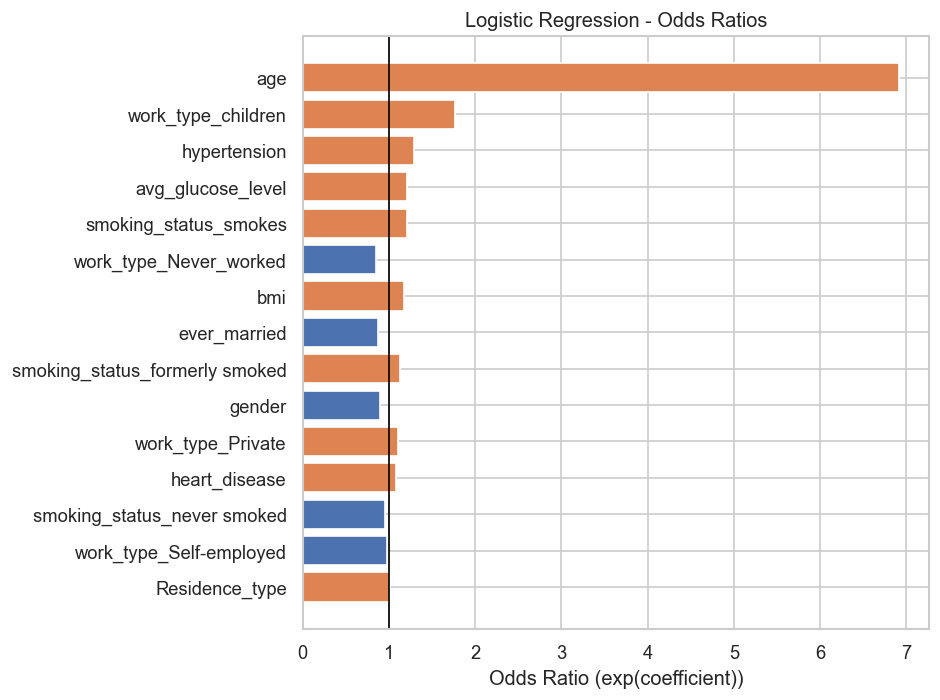

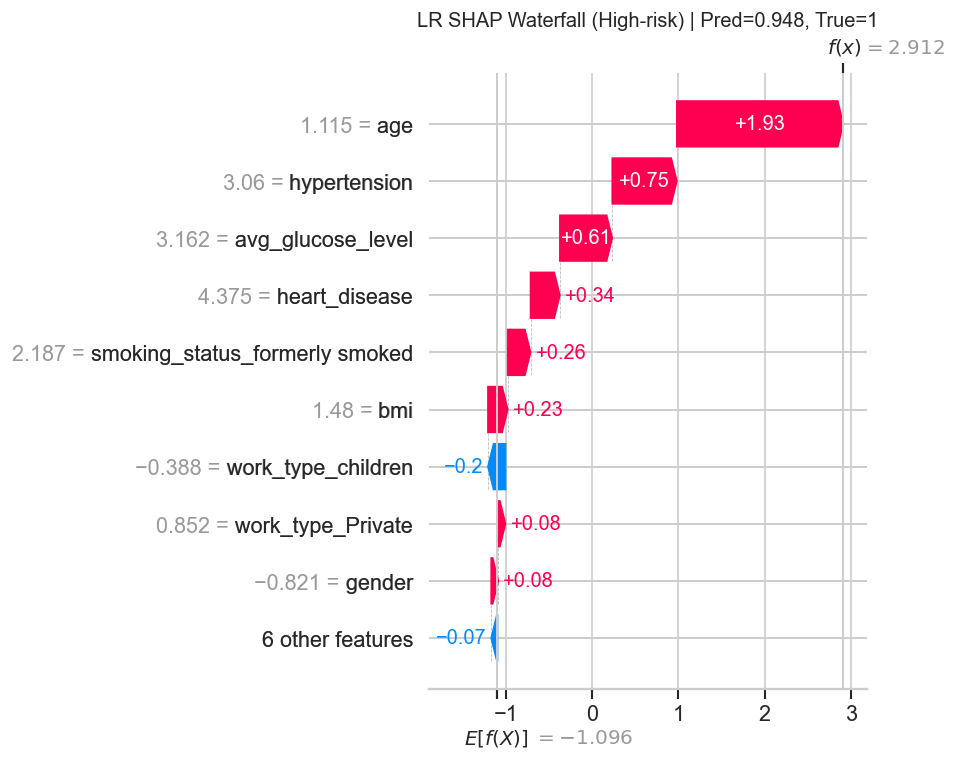

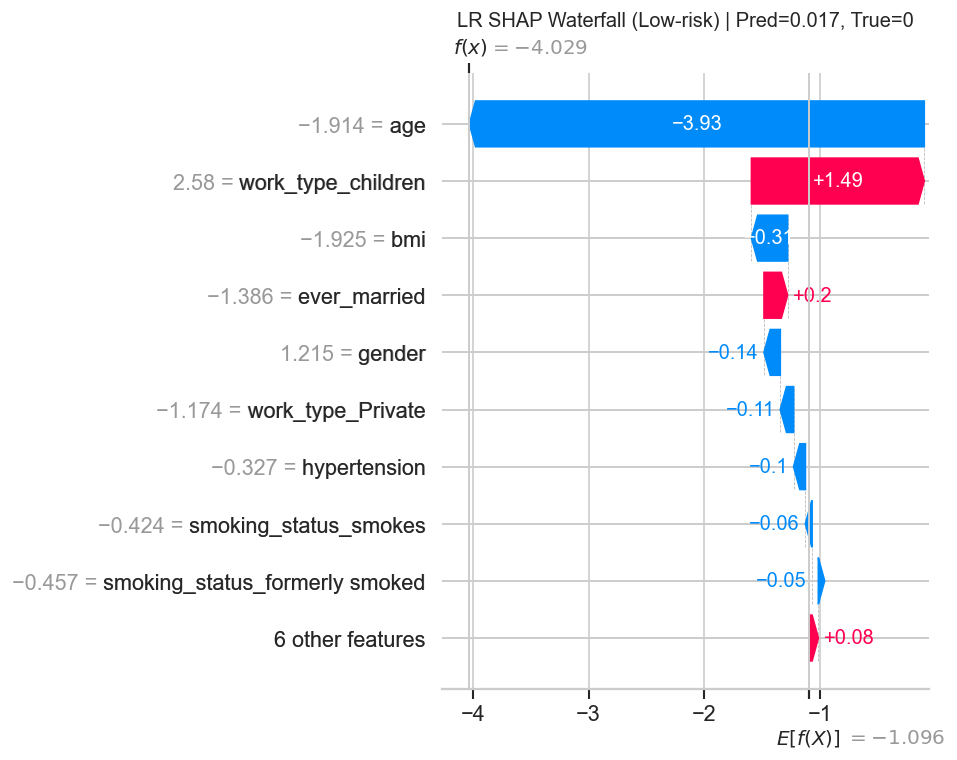

In [6]:
lr_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)

lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred  = lr_model.predict(X_test_scaled)

print("Logistic Regression Report:")
print(classification_report(y_test, lr_pred, zero_division=0))
print(f"ROC-AUC : {roc_auc_score(y_test, lr_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, lr_proba):.4f}")

# -- Global: odds ratios --
coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": lr_model.coef_[0]})
    .assign(odds_ratio=lambda d: np.exp(d["coefficient"]))
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=True)
)

colors = np.where(coef_df["coefficient"] >= 0, "#DD8452", "#4C72B0")
plt.figure(figsize=(8, 6))
plt.barh(coef_df["feature"], coef_df["odds_ratio"], color=colors)
plt.axvline(1.0, color="black", linewidth=1)
plt.title("Logistic Regression - Odds Ratios")
plt.xlabel("Odds Ratio (exp(coefficient))")
plt.tight_layout()
plt.show()

# -- Local: SHAP waterfall --
linear_explainer = shap.LinearExplainer(lr_model, X_train_scaled)

for case_name, pos in patient_cases.items():
    patient_scaled = X_test_scaled.iloc[[pos]]
    true_label     = int(y_test.iloc[pos])
    pred_prob      = float(lr_model.predict_proba(patient_scaled)[:, 1][0])
    shap_vals      = linear_explainer(patient_scaled)
    shap.plots.waterfall(shap_vals[0], show=False)
    plt.title(
        f"LR SHAP Waterfall ({case_name}) | "
        f"Pred={pred_prob:.3f}, True={true_label}"
    )
    plt.tight_layout()
    plt.show()

## 6. Model Comparison

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.8102,0.1909,0.1137,0.6905,0.1953
1,EBM,0.8101,0.1876,0.1119,0.7143,0.1935
2,Classification Tree,0.7871,0.1268,0.1036,0.6905,0.1801


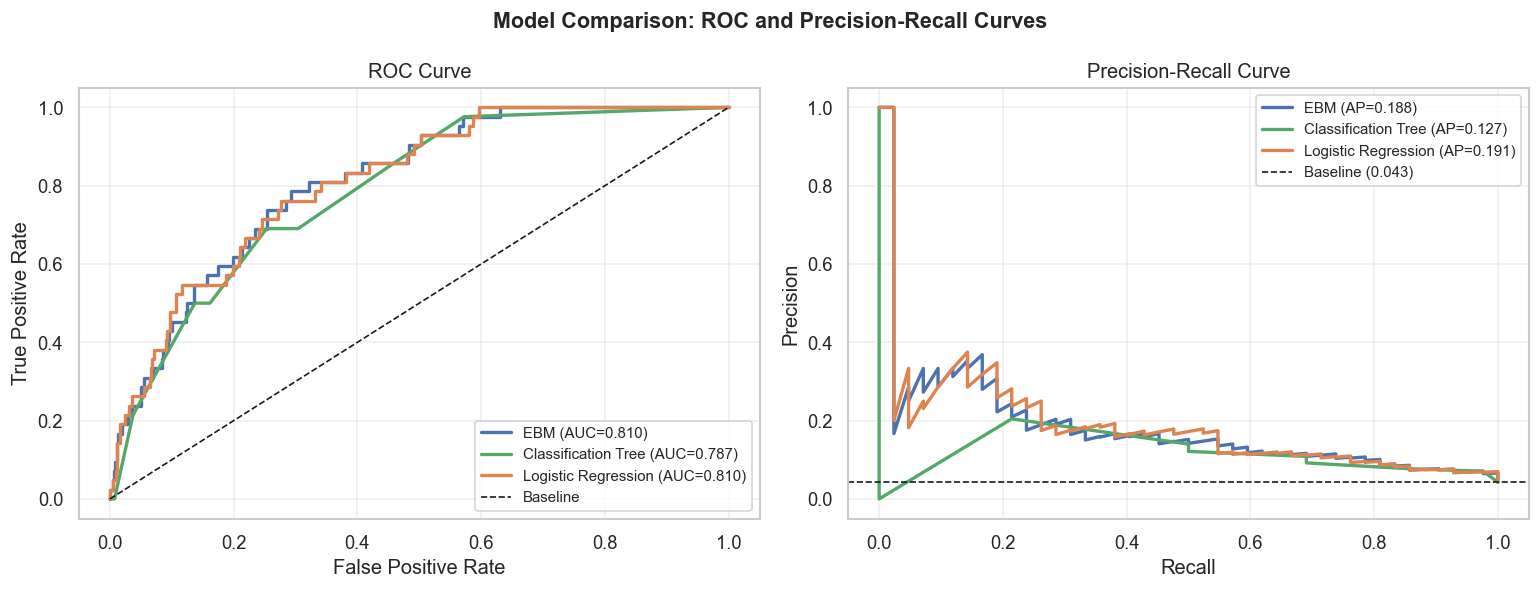

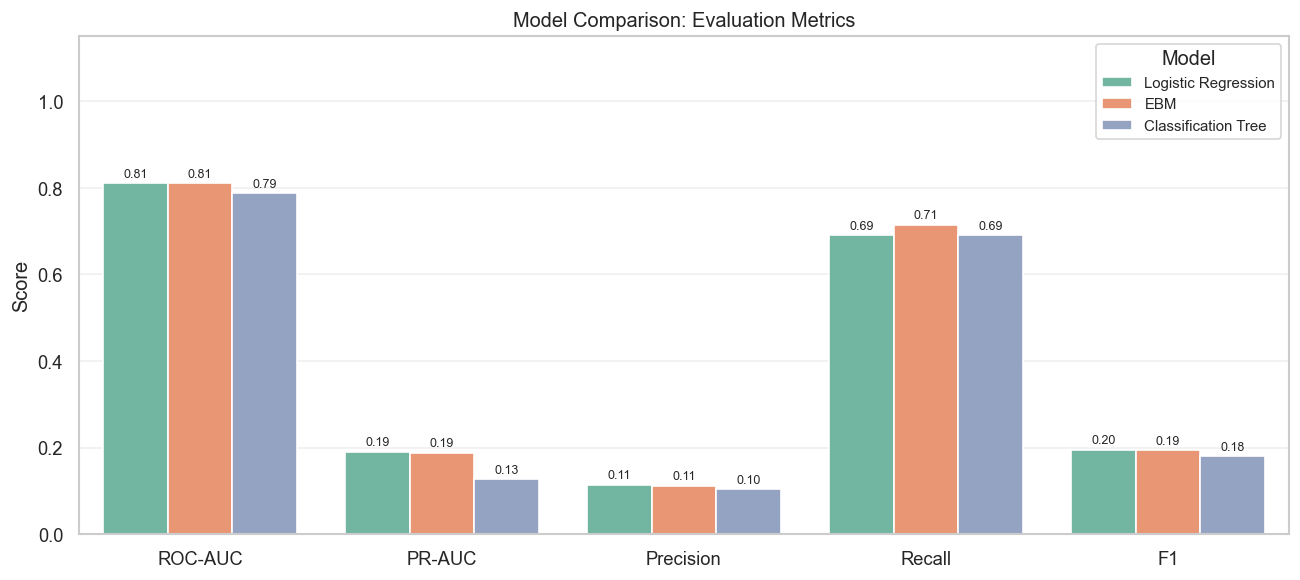

In [7]:
model_outputs = {
    "EBM":                 {"y_score": ebm_proba,  "y_pred": ebm_pred},
    "Classification Tree": {"y_score": tree_proba, "y_pred": tree_pred},
    "Logistic Regression": {"y_score": lr_proba,   "y_pred": lr_pred},
}

roc_curve_data = {}
pr_curve_data  = {}
summary_rows   = []

for name, outputs in model_outputs.items():
    y_score = outputs["y_score"]
    y_pred  = outputs["y_pred"]

    fpr, tpr, _          = roc_curve(y_test, y_score)
    roc_auc              = roc_auc_score(y_test, y_score)
    prec_c, rec_c, _     = precision_recall_curve(y_test, y_score)
    pr_auc               = average_precision_score(y_test, y_score)
    prec, rec, f1, _     = precision_recall_fscore_support(
        y_test, y_pred, average="binary", zero_division=0
    )

    roc_curve_data[name] = {"fpr": fpr, "tpr": tpr, "auc": roc_auc}
    pr_curve_data[name]  = {"precision": prec_c, "recall": rec_c, "ap": pr_auc}
    summary_rows.append({
        "Model": name, "ROC-AUC": roc_auc, "PR-AUC": pr_auc,
        "Precision": prec, "Recall": rec, "F1": f1,
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

display(
    summary_df.style
    .format({c: "{:.4f}" for c in ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1"]})
    .background_gradient(subset=["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1"], cmap="Blues")
)

# -- ROC and PR curves side-by-side --
palette = {
    "EBM":                 "#4C72B0",
    "Classification Tree": "#55A868",
    "Logistic Regression": "#DD8452",
}
baseline_prevalence = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for name, data in roc_curve_data.items():
    ax.plot(data["fpr"], data["tpr"],
            label=f"{name} (AUC={data['auc']:.3f})",
            color=palette[name], linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for name, data in pr_curve_data.items():
    ax.plot(data["recall"], data["precision"],
            label=f"{name} (AP={data['ap']:.3f})",
            color=palette[name], linewidth=2)
ax.axhline(baseline_prevalence, color="k", linestyle="--", linewidth=1,
           label=f"Baseline ({baseline_prevalence:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle("Model Comparison: ROC and Precision-Recall Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# -- Metrics comparison bar chart --
metrics_long = summary_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=metrics_long, x="Metric", y="Score", hue="Model", palette="Set2")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7.5, padding=2)
plt.ylim(0, 1.15)
plt.title("Model Comparison: Evaluation Metrics")
plt.xlabel("")
plt.ylabel("Score")
plt.legend(title="Model", fontsize=9)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()